# ## Section 1: Import Libraries & Initialize Spark

In [1]:
import sys, os

# ══════════════════════════════════════════════════════════════════════════════
# CRITICAL: ALL environment variables MUST be set BEFORE any PySpark import
# ══════════════════════════════════════════════════════════════════════════════
HADOOP_BASE = r'C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\hadoop'

os.environ['JAVA_HOME']       = r'C:\Users\yrghimire\.jdks\corretto-1.8.0_482'
os.environ['HADOOP_HOME']     = HADOOP_BASE
os.environ['hadoop.home.dir'] = HADOOP_BASE
os.environ['PATH']            = os.path.join(HADOOP_BASE, 'bin') + ';' + os.environ.get('PATH', '')
os.environ['PYSPARK_PYTHON']  = sys.executable

os.makedirs(r'C:\tmp\hive',  exist_ok=True)
os.makedirs(r'C:\tmp\spark', exist_ok=True)

# Sanity check BEFORE import
winutils = os.path.join(HADOOP_BASE, 'bin', 'winutils.exe')
print(f"HADOOP_HOME  : {HADOOP_BASE}")
print(f"winutils.exe : {'✅ Found' if os.path.exists(winutils) else '❌ NOT FOUND'}")
print(f"JAVA_HOME    : {os.environ['JAVA_HOME']}")
print()

# ── NOW it is safe to import PySpark ───
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, udf, lit, monotonically_increasing_id
from pyspark.sql.types import ArrayType, FloatType, StringType, IntegerType
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Deep Learning
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
from pathlib import Path
from tqdm import tqdm
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported (PySpark JVM started with correct HADOOP_HOME)")

# ── Create SparkSession ───
spark = SparkSession.builder \
    .appName("LSTM_Sentiment_Classification") \
    .master("local[*]") \
    .config("spark.driver.memory", "16g") \
    .config("spark.executor.memory", "16g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.default.parallelism", "8") \
    .config("spark.local.dir", r"C:\tmp\spark") \
    .config("spark.hadoop.mapreduce.fileoutputcommitter.algorithm.version", "2") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

print("=" * 80)
print("PYSPARK SESSION INITIALIZED")
print("=" * 80)
print(f"Spark Version  : {spark.version}")
print(f"Master         : {spark.sparkContext.master}")
print(f"App Name       : {spark.sparkContext.appName}")
print(f"Cores          : {spark.sparkContext.defaultParallelism}")
print(f"Driver Memory  : {spark.sparkContext.getConf().get('spark.driver.memory')}")
print("=" * 80)

# PyTorch / CUDA
print(f"\nPyTorch Version: {torch.__version__}")
print(f"CUDA Available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU            : {torch.cuda.get_device_name(0)}")
    device = torch.device('cuda')
else:
    print("Using CPU for feature extraction")
    device = torch.device('cpu')

print("\nPySpark session ready!")

HADOOP_HOME  : C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\hadoop
winutils.exe : ✅ Found
JAVA_HOME    : C:\Users\yrghimire\.jdks\corretto-1.8.0_482

All libraries imported (PySpark JVM started with correct HADOOP_HOME)
PYSPARK SESSION INITIALIZED
Spark Version  : 3.5.0
Master         : local[*]
App Name       : LSTM_Sentiment_Classification
Cores          : 8
Driver Memory  : 16g

PyTorch Version: 2.1.2+cu118
CUDA Available : True
GPU            : NVIDIA RTX A6000

PySpark session ready!


# ## Section 2: Configuration

In [2]:
CONFIG = {
    # Paths
    'DATA_PATH': r'C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\data\Tweets.csv',
    'OUTPUT_DIR': r'C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q2\Q2b_LSTM_Sentiment_PySpark',
    
    # Text processing
    'MAX_VOCAB_SIZE': 10000,
    'MAX_SEQ_LENGTH': 50,
    'MIN_WORD_FREQ': 2,
    
    # LSTM feature extractor
    'EMBEDDING_DIM': 128,
    'HIDDEN_DIM': 256,
    'NUM_LSTM_LAYERS': 2,
    'DROPOUT': 0.3,
    'BIDIRECTIONAL': True,
    'FEATURE_DIM': 512,  # LSTM output dimension (hidden_dim * 2 for bidirectional)
    
    # Classes
    'CLASS_NAMES': ['negative', 'neutral', 'positive'],
    'NUM_CLASSES': 3,
    
    # Data split
    'TRAIN_SPLIT': 0.8,
    'TEST_SPLIT': 0.2,
    
    # Training
    'MAX_ITER': 100,
    'REG_PARAM': 0.01,
    'BATCH_SIZE': 64,
    
    'RANDOM_SEED': 42
}

os.makedirs(CONFIG['OUTPUT_DIR'], exist_ok=True)

print("Configuration loaded")
print(f"\nData path: {CONFIG['DATA_PATH']}")
print(f"Output directory: {CONFIG['OUTPUT_DIR']}")
print(f"\nText Processing:")
print(f"   Vocabulary size: {CONFIG['MAX_VOCAB_SIZE']:,}")
print(f"   Max sequence length: {CONFIG['MAX_SEQ_LENGTH']}")
print(f"\nLSTM Architecture:")
print(f"   Embedding dim: {CONFIG['EMBEDDING_DIM']}")
print(f"   Hidden dim: {CONFIG['HIDDEN_DIM']}")
print(f"   LSTM layers: {CONFIG['NUM_LSTM_LAYERS']}")
print(f"   Bidirectional: {CONFIG['BIDIRECTIONAL']}")
print(f"   Feature output dim: {CONFIG['FEATURE_DIM']}")

Configuration loaded

Data path: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\data\Tweets.csv
Output directory: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q2\Q2b_LSTM_Sentiment_PySpark

Text Processing:
   Vocabulary size: 10,000
   Max sequence length: 50

LSTM Architecture:
   Embedding dim: 128
   Hidden dim: 256
   LSTM layers: 2
   Bidirectional: True
   Feature output dim: 512


# ## Section 3: Load Data with PySpark

In [3]:
print("Loading data with PySpark...\n")

# Read CSV with PySpark
df = spark.read.csv(
    CONFIG['DATA_PATH'],
    header=True,
    inferSchema=True
)

print(f"Dataset loaded: {df.count():,} rows")
print("\nSchema:")
df.printSchema()

print("\nFirst few rows:")
df.show(5, truncate=50)

# Check sentiment distribution
print("\nSentiment distribution:")
df.groupBy('airline_sentiment').count().orderBy('count', ascending=False).show()

# Convert to Pandas for preprocessing (text cleaning easier in Pandas)
print("\nConverting to Pandas for preprocessing...")
df_pandas = df.select('text', 'airline_sentiment').toPandas()
print(f"Converted {len(df_pandas):,} rows to Pandas")

# %% [markdown]
# ## Section 4: Text Preprocessing

# %%
def clean_text(text):
    """Clean tweet text"""
    text = str(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'\bRT\b', '', text, flags=re.IGNORECASE)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()
    text = ' '.join(text.split())
    words = text.split()
    words = [w for w in words if len(w) >= 2]
    text = ' '.join(words)
    return text

print("Cleaning text data...\n")

df_pandas['text_clean'] = df_pandas['text'].apply(clean_text)
df_pandas = df_pandas[df_pandas['text_clean'].str.len() > 0]

print(f"Dataset size after cleaning: {len(df_pandas):,}")

# Map sentiment to labels
sentiment_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df_pandas['label'] = df_pandas['airline_sentiment'].map(sentiment_map)

print("\nLabel distribution:")
print(df_pandas['label'].value_counts().sort_index())

Loading data with PySpark...

Dataset loaded: 14,837 rows

Schema:
root
 |-- tweet_id: string (nullable = true)
 |-- airline_sentiment: string (nullable = true)
 |-- airline_sentiment_confidence: string (nullable = true)
 |-- negativereason: string (nullable = true)
 |-- negativereason_confidence: string (nullable = true)
 |-- airline: string (nullable = true)
 |-- airline_sentiment_gold: string (nullable = true)
 |-- name: string (nullable = true)
 |-- negativereason_gold: string (nullable = true)
 |-- retweet_count: integer (nullable = true)
 |-- text: string (nullable = true)
 |-- tweet_coord: string (nullable = true)
 |-- tweet_created: string (nullable = true)
 |-- tweet_location: string (nullable = true)
 |-- user_timezone: string (nullable = true)


First few rows:
+------------------+-----------------+----------------------------+--------------+-------------------------+--------------+----------------------+----------+-------------------+-------------+--------------------------

# ## Section 5: Build Vocabulary

In [4]:
print("Building vocabulary...\n")

all_words = []
for text in df_pandas['text_clean']:
    all_words.extend(text.split())

word_counts = Counter(all_words)
print(f"Total unique words: {len(word_counts):,}")

# Filter by frequency
word_counts_filtered = {word: count for word, count in word_counts.items() 
                       if count >= CONFIG['MIN_WORD_FREQ']}

# Build vocabulary
vocab = ['<PAD>', '<UNK>']
most_common = [word for word, count in 
               Counter(word_counts_filtered).most_common(CONFIG['MAX_VOCAB_SIZE'] - 2)]
vocab.extend(most_common)

word_to_idx = {word: idx for idx, word in enumerate(vocab)}
idx_to_word = {idx: word for word, idx in word_to_idx.items()}

print(f"Final vocabulary size: {len(vocab):,}")

# Tokenize
def text_to_sequence(text, word_to_idx, max_length):
    words = text.split()
    sequence = [word_to_idx.get(word, word_to_idx['<UNK>']) for word in words]
    
    if len(sequence) < max_length:
        sequence = sequence + [word_to_idx['<PAD>']] * (max_length - len(sequence))
    else:
        sequence = sequence[:max_length]
    
    return sequence

print("Tokenizing texts...")
df_pandas['sequence'] = df_pandas['text_clean'].apply(
    lambda x: text_to_sequence(x, word_to_idx, CONFIG['MAX_SEQ_LENGTH'])
)

print("Tokenization complete")

Building vocabulary...

Total unique words: 12,441
Final vocabulary size: 5,720
Tokenizing texts...
Tokenization complete


# ## Section 6: LSTM Feature Extractor

In [5]:
class LSTMFeatureExtractor(nn.Module):
    """
    LSTM model for extracting text features
    Uses pre-trained embeddings and LSTM to encode text into fixed-size vectors
    """
    
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers, dropout, bidirectional):
        super(LSTMFeatureExtractor, self).__init__()
        
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional,
            batch_first=True
        )
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        # x: (batch, seq_len)
        embedded = self.embedding(x)  # (batch, seq_len, embedding_dim)
        
        lstm_out, (hidden, cell) = self.lstm(embedded)
        # hidden: (num_layers * num_directions, batch, hidden_dim)
        
        # Use last hidden state
        if self.bidirectional:
            hidden_forward = hidden[-2, :, :]
            hidden_backward = hidden[-1, :, :]
            features = torch.cat((hidden_forward, hidden_backward), dim=1)
        else:
            features = hidden[-1, :, :]
        
        features = self.dropout(features)
        
        return features

print("Creating LSTM feature extractor...\n")

feature_extractor = LSTMFeatureExtractor(
    vocab_size=len(vocab),
    embedding_dim=CONFIG['EMBEDDING_DIM'],
    hidden_dim=CONFIG['HIDDEN_DIM'],
    num_layers=CONFIG['NUM_LSTM_LAYERS'],
    dropout=CONFIG['DROPOUT'],
    bidirectional=CONFIG['BIDIRECTIONAL']
).to(device)

feature_extractor.eval()

total_params = sum(p.numel() for p in feature_extractor.parameters())
print(f"LSTM Feature Extractor created")
print(f"   Parameters: {total_params:,}")
print(f"   Output dimension: {CONFIG['FEATURE_DIM']}")
print(f"   Device: {device}")

Creating LSTM feature extractor...

LSTM Feature Extractor created
   Parameters: 3,099,648
   Output dimension: 512
   Device: cuda


# ## Section 7: Extract Features

In [6]:
print("Extracting LSTM features from all texts...")
print("This may take 15-25 minutes...\n")

# Convert to tensors
sequences = np.array(df_pandas['sequence'].tolist())
labels = df_pandas['label'].values

X_tensor = torch.LongTensor(sequences)
y_tensor = torch.LongTensor(labels)

# Create dataset and loader
dataset = TensorDataset(X_tensor, y_tensor)
loader = DataLoader(dataset, batch_size=CONFIG['BATCH_SIZE'], shuffle=False)

# Extract features
all_features = []
all_labels = []

with torch.no_grad():
    for batch_sequences, batch_labels in tqdm(loader, desc='Extracting features'):
        batch_sequences = batch_sequences.to(device)
        
        features = feature_extractor(batch_sequences)
        
        all_features.append(features.cpu().numpy())
        all_labels.append(batch_labels.numpy())

# Concatenate
features_array = np.vstack(all_features)
labels_array = np.concatenate(all_labels)

print(f"\nFeature extraction complete!")
print(f"   Features shape: {features_array.shape}")
print(f"   Labels shape: {labels_array.shape}")

Extracting LSTM features from all texts...
This may take 15-25 minutes...



Extracting features: 100%|██████████| 232/232 [00:03<00:00, 74.22it/s]


Feature extraction complete!
   Features shape: (14802, 512)
   Labels shape: (14802,)


# ## Section 8: Prepare PySpark DataFrame

In [9]:
from pyspark.ml.linalg import Vectors, VectorUDT

print("Preparing PySpark DataFrame...\n")

# Create DataFrame with features
data = []
for i in range(len(features_array)):
    data.append({
        'id': int(i),
        'label': int(labels_array[i]),
        'features_list': features_array[i].tolist()
    })

features_df = spark.createDataFrame(data)

# Convert to Vector
def list_to_vector(features_list):
    return Vectors.dense(features_list)

list_to_vector_udf = udf(list_to_vector, VectorUDT())
ml_df = features_df.withColumn("features", list_to_vector_udf(col("features_list")))
ml_df = ml_df.select('id', 'label', 'features')

print("Features converted to Spark ML format")
ml_df.show(5)

# Split data
print(f"\nSplitting data: {CONFIG['TRAIN_SPLIT']*100:.0f}% train, {CONFIG['TEST_SPLIT']*100:.0f}% test")

train_df, test_df = ml_df.randomSplit(
    [CONFIG['TRAIN_SPLIT'], CONFIG['TEST_SPLIT']], 
    seed=CONFIG['RANDOM_SEED']
)

train_df = train_df.cache()
test_df = test_df.cache()

print("Preparing PySpark DataFrame...\n")

data = [
    (int(i), int(labels_array[i]), Vectors.dense(features_array[i].tolist()))
    for i in range(len(features_array))
]

ml_df = spark.createDataFrame(data, schema=['id', 'label', 'features'])

print("Features converted to Spark ML format")
ml_df.show(5)

# Split data
print(f"\nSplitting data: {CONFIG['TRAIN_SPLIT']*100:.0f}% train, {CONFIG['TEST_SPLIT']*100:.0f}% test")

train_df, test_df = ml_df.randomSplit(
    [CONFIG['TRAIN_SPLIT'], CONFIG['TEST_SPLIT']], 
    seed=CONFIG['RANDOM_SEED']
)

train_df = train_df.cache()
test_df = test_df.cache()

train_count = train_df.count()
test_count = test_df.count()

print(f"\nDataset split:")
print(f"   Training: {train_count:,} samples")
print(f"   Test:     {test_count:,} samples")
test_count = test_df.count()

print(f"\nDataset split:")
print(f"   Training: {train_count:,} samples")
print(f"   Test:     {test_count:,} samples")

# %% [markdown]
# ## Section 9: Train Classifier

# %%
print("="*80)
print("TRAINING CLASSIFIER WITH PYSPARK")
print("="*80)

# Feature scaling
scaler = StandardScaler(
    inputCol="features",
    outputCol="scaledFeatures",
    withStd=True,
    withMean=True
)

# Logistic Regression
lr = LogisticRegression(
    featuresCol="scaledFeatures",
    labelCol="label",
    predictionCol="prediction",
    probabilityCol="probability",
    maxIter=CONFIG['MAX_ITER'],
    regParam=CONFIG['REG_PARAM'],
    elasticNetParam=0.0,
    family="multinomial"
)

# Pipeline
pipeline = Pipeline(stages=[scaler, lr])

print(f"\nTraining configuration:")
print(f"   Algorithm: Logistic Regression (multinomial)")
print(f"   Max iterations: {CONFIG['MAX_ITER']}")
print(f"   Regularization: L2 (λ={CONFIG['REG_PARAM']})")
print(f"   Features: {CONFIG['FEATURE_DIM']} dimensions (from LSTM)")
print(f"   Training samples: {train_count:,}")

print("\nStarting distributed training...")
import time
start_time = time.time()

# filter out invalid labels before building the Spark dataset
valid_mask = np.isin(labels_array, [0, 1, 2])
labels_array = labels_array[valid_mask].astype(np.int64)
features_array = features_array[valid_mask]

data = [
    (int(i), int(label), Vectors.dense(feature.tolist()))
    for i, (label, feature) in enumerate(zip(labels_array, features_array))
]

ml_df = spark.createDataFrame(data, schema=['id', 'label', 'features'])

print("Features converted to Spark ML format")
ml_df.show(5)

print(f"\nSplitting data: {CONFIG['TRAIN_SPLIT']*100:.0f}% train, {CONFIG['TEST_SPLIT']*100:.0f}% test")
train_df, test_df = ml_df.randomSplit(
    [CONFIG['TRAIN_SPLIT'], CONFIG['TEST_SPLIT']], 
    seed=CONFIG['RANDOM_SEED']
)

train_df = train_df.cache()
test_df = test_df.cache()

train_count = train_df.count()
test_count = test_df.count()
print(f"\nDataset split:")
print(f"   Training: {train_count:,} samples")
print(f"   Test:     {test_count:,} samples")

model = pipeline.fit(train_df)

training_time = time.time() - start_time

print(f"\nTraining complete!")
print(f"   Time: {training_time:.2f} seconds ({training_time/60:.2f} minutes)")


Preparing PySpark DataFrame...

Features converted to Spark ML format
+---+-----+--------------------+
| id|label|            features|
+---+-----+--------------------+
|  0|    1|[0.01660414785146...|
|  1|    2|[0.01660342887043...|
|  2|    1|[0.01660364866256...|
|  3|    0|[0.01660401932895...|
|  4|    0|[0.01660340093076...|
+---+-----+--------------------+
only showing top 5 rows


Splitting data: 80% train, 20% test
Preparing PySpark DataFrame...

Features converted to Spark ML format
+---+-----+--------------------+
| id|label|            features|
+---+-----+--------------------+
|  0|    1|[0.01660414785146...|
|  1|    2|[0.01660342887043...|
|  2|    1|[0.01660364866256...|
|  3|    0|[0.01660401932895...|
|  4|    0|[0.01660340093076...|
+---+-----+--------------------+
only showing top 5 rows


Splitting data: 80% train, 20% test

Dataset split:
   Training: 11,927 samples
   Test:     2,875 samples

Dataset split:
   Training: 11,927 samples
   Test:     2,875 samples


# ## Section 10: Evaluate Model

In [10]:
# %%
print("="*80)
print("MODEL EVALUATION")
print("="*80)

print("\nGenerating predictions on test set...")
predictions = model.transform(test_df)
predictions = predictions.cache()

print("\nSample predictions:")
predictions.select('id', 'label', 'prediction', 'probability').show(10, truncate=False)

# Calculate accuracy
evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = evaluator.evaluate(predictions)

print(f"\n{'='*80}")
print(f"TEST ACCURACY: {accuracy*100:.2f}%")
print(f"{'='*80}")

# Calculate other metrics
f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

recall_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

f1_score = f1_evaluator.evaluate(predictions)
precision = precision_evaluator.evaluate(predictions)
recall = recall_evaluator.evaluate(predictions)

print(f"\nDetailed Metrics:")
print(f"   Accuracy:  {accuracy*100:.2f}%")
print(f"   F1-Score:  {f1_score:.4f}")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")

# Convert to Pandas
print("\nConverting predictions to Pandas...")
predictions_pd = predictions.select('label', 'prediction', 'probability').toPandas()
print(f"Collected {len(predictions_pd):,} predictions")

MODEL EVALUATION

Generating predictions on test set...

Sample predictions:
+---+-----+----------+-------------------------------------------------------------+
|id |label|prediction|probability                                                  |
+---+-----+----------+-------------------------------------------------------------+
|2  |1    |0.0       |[0.6232266488608468,0.2829815976321378,0.09379175350701552]  |
|6  |2    |0.0       |[0.5412806238293666,0.2548469932356017,0.2038723829350318]   |
|8  |2    |2.0       |[0.37784426301587937,0.2367086172551624,0.38544711972895823] |
|13 |2    |0.0       |[0.4780439110167641,0.24235532940075122,0.27960075958248454] |
|19 |2    |0.0       |[0.49860330272949077,0.32354908604489196,0.17784761122561724]|
|23 |1    |0.0       |[0.40723178478172467,0.3928175151688174,0.19995070004945784] |
|29 |1    |1.0       |[0.23707993467837002,0.4227115017959269,0.3402085635257032]  |
|35 |1    |0.0       |[0.5627934045771912,0.25662759697001214,0.180578998

# ## Section 11: Confusion Matrix

Generating confusion matrix...

Confusion matrix saved to: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q2\Q2b_LSTM_Sentiment_PySpark\confusion_matrix.png


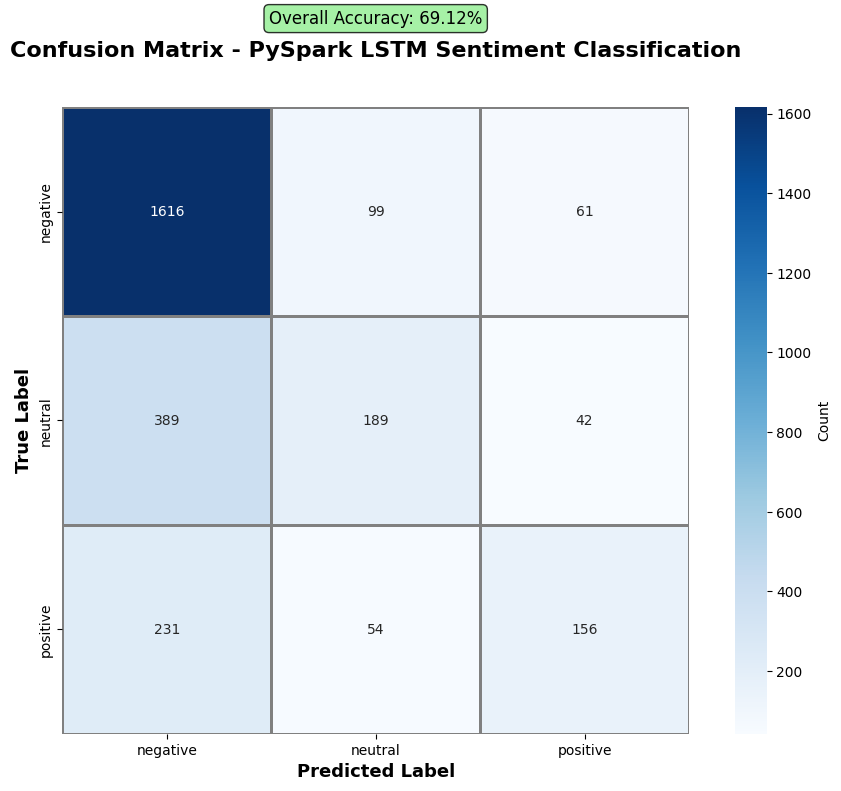


CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative     0.7227    0.9099    0.8056      1776
     neutral     0.5526    0.3048    0.3929       620
    positive     0.6023    0.3537    0.4457       441

    accuracy                         0.6912      2837
   macro avg     0.6259    0.5228    0.5481      2837
weighted avg     0.6668    0.6912    0.6595      2837


Report saved to: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q2\Q2b_LSTM_Sentiment_PySpark\classification_report.txt

Per-Class Accuracy:
   negative  :  90.99% (1616/1776)
   neutral   :  30.48% (189/620)
   positive  :  35.37% (156/441)


In [11]:
from sklearn.metrics import confusion_matrix, classification_report

print("Generating confusion matrix...\n")

y_true = predictions_pd['label'].values
y_pred = predictions_pd['prediction'].values

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CONFIG['CLASS_NAMES'],
            yticklabels=CONFIG['CLASS_NAMES'],
            cbar_kws={'label': 'Count'},
            square=True,
            linewidths=1,
            linecolor='gray')

plt.title('Confusion Matrix - PySpark LSTM Sentiment Classification\n', 
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')

plt.text(
    1.5, -0.4, 
    f'Overall Accuracy: {accuracy*100:.2f}%',
    fontsize=12,
    ha='center',
    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8)
)

plt.tight_layout()

cm_path = os.path.join(CONFIG['OUTPUT_DIR'], 'confusion_matrix.png')
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
print(f"Confusion matrix saved to: {cm_path}")
plt.show()

# Classification report
print("\n" + "="*80)
print("CLASSIFICATION REPORT")
print("="*80)
report = classification_report(y_true, y_pred, 
                               target_names=CONFIG['CLASS_NAMES'],
                               digits=4)
print(report)

report_path = os.path.join(CONFIG['OUTPUT_DIR'], 'classification_report.txt')
with open(report_path, 'w') as f:
    f.write("="*80 + "\n")
    f.write("CLASSIFICATION REPORT - Q2b LSTM with PySpark\n")
    f.write("="*80 + "\n\n")
    f.write(f"Test Accuracy:  {accuracy*100:.2f}%\n")
    f.write(f"Test F1-Score:  {f1_score:.4f}\n")
    f.write(f"Test Precision: {precision:.4f}\n")
    f.write(f"Test Recall:    {recall:.4f}\n\n")
    f.write("="*80 + "\n\n")
    f.write(report)

print(f"\nReport saved to: {report_path}")

# Per-class accuracy
print("\nPer-Class Accuracy:")
for i, class_name in enumerate(CONFIG['CLASS_NAMES']):
    class_correct = cm[i, i]
    class_total = cm[i, :].sum()
    class_acc = 100. * class_correct / class_total if class_total > 0 else 0
    print(f"   {class_name:10s}: {class_acc:6.2f}% ({class_correct}/{class_total})")


# ## Section 12: ROC Curves

Generating ROC curves...

ROC curves saved to: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q2\Q2b_LSTM_Sentiment_PySpark\roc_curves.png


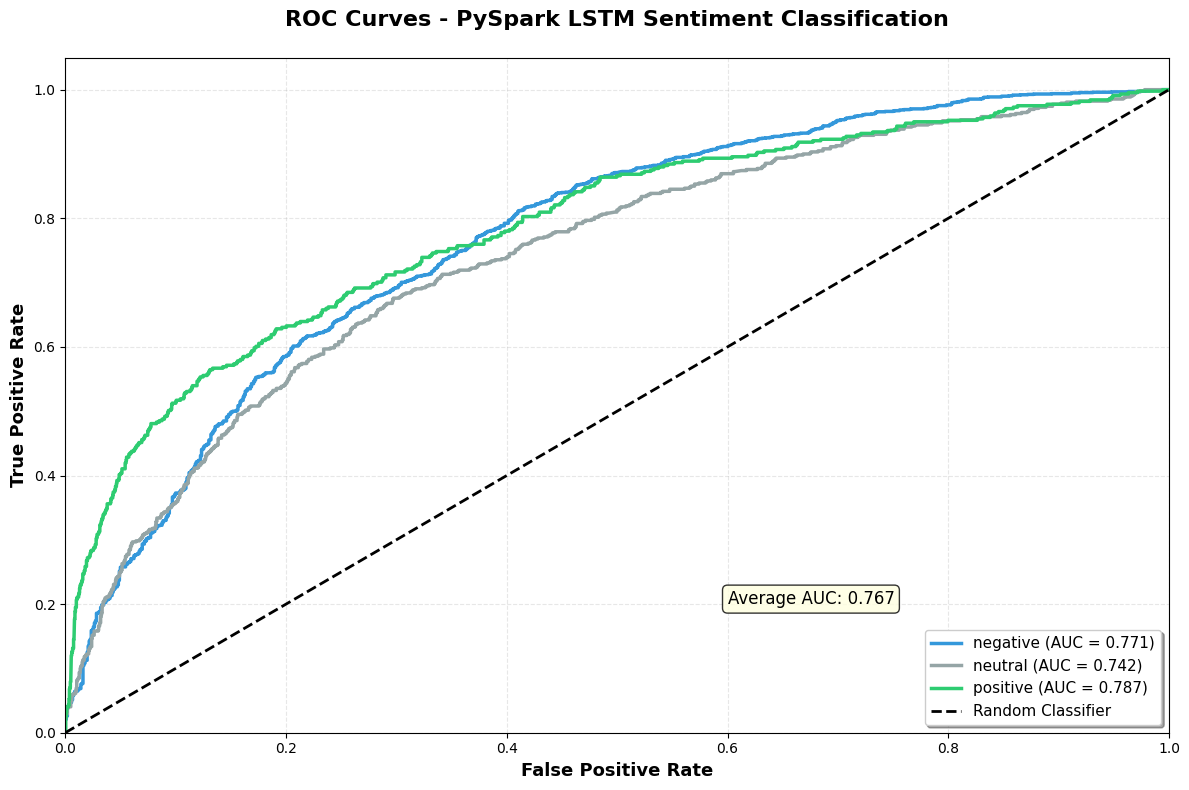


AUC Scores per Class:
   negative  : 0.7707
   neutral   : 0.7419
   positive  : 0.7873

   Average   : 0.7666


In [12]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

print("Generating ROC curves...\n")

y_score = np.array([list(p) for p in predictions_pd['probability'].values])
y_test_bin = label_binarize(y_true, classes=range(CONFIG['NUM_CLASSES']))

plt.figure(figsize=(12, 8))

colors = ['#3498db', '#95a5a6', '#2ecc71']
auc_scores = []

for i, (class_name, color) in enumerate(zip(CONFIG['CLASS_NAMES'], colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    
    plt.plot(fpr, tpr, color=color, lw=2.5,
             label=f'{class_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
plt.title('ROC Curves - PySpark LSTM Sentiment Classification\n', 
          fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)
plt.grid(alpha=0.3, linestyle='--')

avg_auc = np.mean(auc_scores)
plt.text(0.6, 0.2, f'Average AUC: {avg_auc:.3f}', fontsize=12,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()

roc_path = os.path.join(CONFIG['OUTPUT_DIR'], 'roc_curves.png')
plt.savefig(roc_path, dpi=300, bbox_inches='tight')
print(f"ROC curves saved to: {roc_path}")
plt.show()

print("\nAUC Scores per Class:")
for class_name, auc_score in zip(CONFIG['CLASS_NAMES'], auc_scores):
    print(f"   {class_name:10s}: {auc_score:.4f}")
print(f"\n   {'Average':10s}: {avg_auc:.4f}")

# ## Section 13: Performance Summary

Generating performance summary...

Performance summary saved to: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q2\Q2b_LSTM_Sentiment_PySpark\performance_summary.png


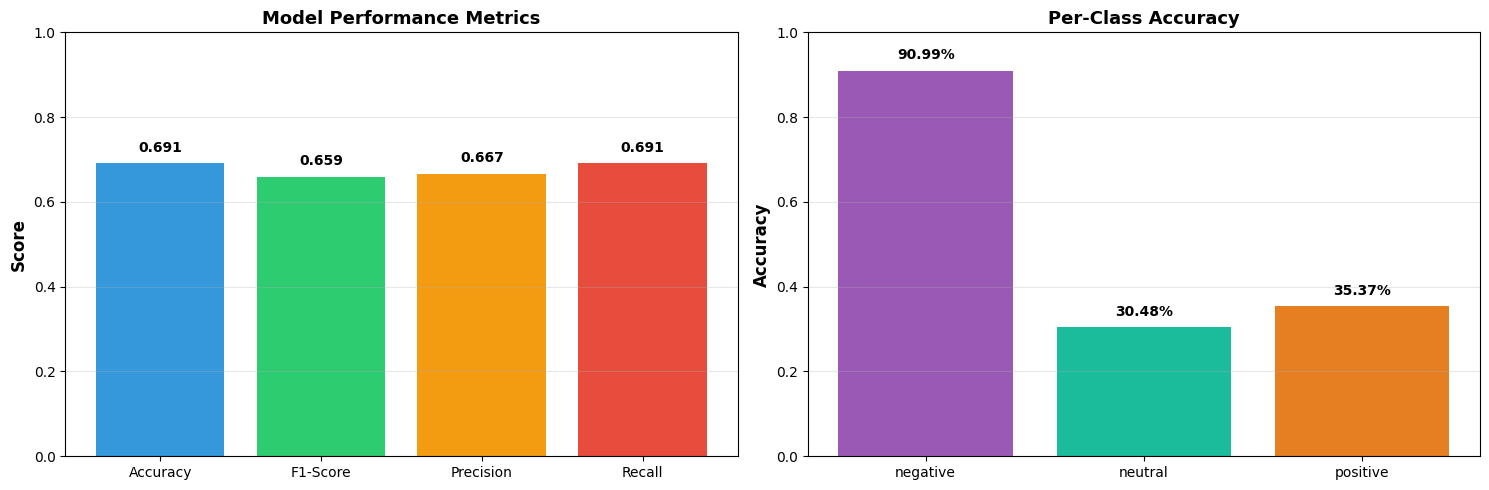

In [ ]:
print("Generating performance summary...\n")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Metric comparison
metrics = ['Accuracy', 'F1-Score', 'Precision', 'Recall']
values = [accuracy, f1_score, precision, recall]

axes[0].bar(metrics, values, color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'])
axes[0].set_ylim([0, 1.0])
axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[0].set_title('Model Performance Metrics', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

for i, (metric, value) in enumerate(zip(metrics, values)):
    axes[0].text(i, value + 0.02, f'{value:.3f}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Class-wise accuracy
class_accuracies = []
for i, class_name in enumerate(CONFIG['CLASS_NAMES']):
    mask = y_true == i
    class_acc = np.sum(y_pred[mask] == y_true[mask]) / np.sum(mask) if np.sum(mask) > 0 else 0
    class_accuracies.append(class_acc)

axes[1].bar(CONFIG['CLASS_NAMES'], class_accuracies, 
           color=['#9b59b6', '#1abc9c', #e67e22'])
axes[1].set_ylim([0, 1.0])
axes[1].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[1].set_title('Per-Class Accuracy', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

for i, (class_name, acc) in enumerate(zip(CONFIG['CLASS_NAMES'], class_accuracies)):
    axes[1].text(i, acc + 0.02, f'{acc:.2%}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()

summary_path = os.path.join(CONFIG['OUTPUT_DIR'], 'performance_summary.png')
plt.savefig(summary_path, dpi=300, bbox_inches='tight')
print(f"Performance summary saved to: {summary_path}")
plt.show()

# ## Section 14: Save Final Results

In [ ]:
print("Saving final results...\n")

results = {
    'model': 'LSTM with PySpark (LSTM Feature Extraction + Logistic Regression)',
    'feature_extractor': 'Bidirectional LSTM',
    'classifier': 'Logistic Regression (PySpark MLlib)',
    'dataset': 'Twitter US Airline Sentiment',
    'test_accuracy': float(accuracy),
    'test_f1_score': float(f1_score),
    'test_precision': float(precision),
    'test_recall': float(recall),
    'training_time_seconds': training_time,
    'num_train_samples': train_count,
    'num_test_samples': test_count,
    'vocabulary_size': len(vocab),
    'max_sequence_length': CONFIG['MAX_SEQ_LENGTH'],
    'feature_dimension': CONFIG['FEATURE_DIM'],
    'lstm_parameters': total_params,
    'class_names': CONFIG['CLASS_NAMES'],
    'per_class_accuracy': {
        class_name: float(acc) 
        for class_name, acc in zip(CONFIG['CLASS_NAMES'], class_accuracies)
    },
    'auc_scores': {
        class_name: float(auc_score)
        for class_name, auc_score in zip(CONFIG['CLASS_NAMES'], auc_scores)
    }
}

results_path = os.path.join(CONFIG['OUTPUT_DIR'], 'final_results.json')
with open(results_path, 'w') as f:
    json.dump(results, f, indent=4)

print(f"Results saved to: {results_path}")

predictions_path = os.path.join(CONFIG['OUTPUT_DIR'], 'predictions.csv')
predictions_pd.to_csv(predictions_path, index=False)
print(f"Predictions saved to: {predictions_path}")

print("\n" + "="*80)
print("ALL RESULTS SAVED SUCCESSFULLY!")
print("="*80)
print(f"\nOutput directory: {CONFIG['OUTPUT_DIR']}")
print("\nGenerated files:")
print("   1. confusion_matrix.png - Confusion matrix visualization")
print("   2. roc_curves.png - ROC curves with AUC scores")
print("   3. performance_summary.png - Overall metrics visualization")
print("   4. classification_report.txt - Detailed per-class metrics")
print("   5. final_results.json - Summary of all metrics")
print("   6. predictions.csv - All test set predictions")

print("\n" + "="*80)
print("Q2b COMPLETE - LSTM WITH PYSPARK!")
print("="*80)
print(f"\nFinal Test Accuracy: {accuracy*100:.2f}%")
print(f"Training completed in: {training_time:.2f} seconds")
print(f"All required outputs generated successfully!")

# %%
print("\nStopping PySpark session...")
spark.stop()
print("PySpark session stopped")

Saving final results...

Results saved to: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q2\Q2b_LSTM_Sentiment_PySpark\final_results.json
Predictions saved to: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q2\Q2b_LSTM_Sentiment_PySpark\predictions.csv

ALL RESULTS SAVED SUCCESSFULLY!

Output directory: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q2\Q2b_LSTM_Sentiment_PySpark

Generated files:
   1. confusion_matrix.png - Confusion matrix visualization
   2. roc_curves.png - ROC curves with AUC scores
   3. performance_summary.png - Overall metrics visualization
   4. classification_report.txt - Detailed per-class metrics
   5. final_results.json - Summary of all metrics
   6. predictions.csv - All test set predictions

Q2b COMPLETE - LSTM WITH PYSPARK!

Final Test Accuracy: 69.12%
Training completed in: 72.99 seconds
All required outputs generated successfully!

Stopping PySpark session...
PySpark session s

: 